#**Forecasting Omaha Temperatures Using Recurrent Neural Networks Code**

#**1. Enviroment Setup**

In [15]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from keras.models import Sequential
from keras.layers import InputLayer, LSTM, Dense, Dropout, BatchNormalization, Bidirectional

#**2. Prepare Data**

#**2.1 Read Data**

In [16]:
df = pd.read_csv("Omaha_Temp_Data.csv") #create dataframe
df = df.drop(['wdir', 'wpgt', 'tsun'], axis = 1) #remove NaN columns

# Convert temperatures to Farenheight
df['tmax'] = df['tmax'] * 9/5 + 32
df['tmin'] = df['tmin'] * 9/5 + 32
df['tavg'] = df['tavg'] * 9/5 + 32

# Add additional predictor features
df["diurnal_range"] = df["tmax"] - df["tmin"]
df["tmax_lag1"] = df["tmax"].shift(1)
df["tmin_lag1"] = df["tmin"].shift(1)
df["tmax_lag2"] = df["tmax"].shift(2)
df["tmin_lag2"] = df["tmin"].shift(2)

df = df.dropna().reset_index(drop=True)

#**2.2 Normalize Data**

In [17]:
# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Save dates so we can reattach later
dates = df['date']

# Columns to scale (exclude date)
feature_cols = df.drop(["date", "tmax", "tmin"], axis=1).columns

# Fit feature scaler using pre-2020 data
feature_scaler = MinMaxScaler()
feature_scaler.fit(df[df["date"].dt.year < 2024][feature_cols])

# Fit temperature scaler for tmin/tmax only
temp_scaler = MinMaxScaler()
temp_scaler.fit(df[df["date"].dt.year < 2024][["tmin","tmax"]])

# Create scaled dataframe
scaled_df = df.copy()
scaled_df[feature_cols] = feature_scaler.transform(df[feature_cols])
scaled_df[["tmin","tmax"]] = temp_scaler.transform(df[["tmin","tmax"]])
scaled_df["date"] = dates

#**2.3 Construct Training and Testing Sequences**

In [18]:
# Only winter months (Dec, Jan, Feb) for training the winter model
winter_filter = scaled_df['date'].dt.month.isin([12, 1, 2])
scaled_df_winter = scaled_df[winter_filter].copy()

# Only spring months (Mar, Apr, May) for training the spring model
spring_filter = scaled_df['date'].dt.month.isin([3, 4, 5])
scaled_df_spring = scaled_df[spring_filter].copy()

# Only summer months (Jun, Jul, Aug) for training the summer model
summer_filter = scaled_df['date'].dt.month.isin([6, 7, 8])
scaled_df_summer = scaled_df[summer_filter].copy()

# Only fall months (Sep, Oct, Nov) for training the fall model
fall_filter = scaled_df['date'].dt.month.isin([9, 10, 11])
scaled_df_fall = scaled_df[fall_filter].copy()

def build_training_sequences(df, cutoff_date, seq_len):
    df = df[df["date"] < cutoff_date].sort_values("date").reset_index(drop=True)
    features = df.drop(["date", "tmax", "tmin"], axis=1).values
    targets  = df[["tmin", "tmax"]].values
    x, y = [], []
    for i in range(len(df) - seq_len - 1):
        x.append(features[i : i + seq_len])
        y.append(targets[i + seq_len])
    return np.array(x), np.array(y)

def build_test_sequences(df, start_day, end_day, month, seq_len=7):
    start_date = pd.Timestamp(year=2024, month=month, day=start_day)
    end_date   = pd.Timestamp(year=2024, month=month, day=end_day)
    history = df[df["date"] < start_date].sort_values("date").reset_index(drop=True)
    x_window = history.tail(seq_len)
    y_window = df[(df["date"] >= start_date) & (df["date"] <= end_date)] \
                 . sort_values("date")
    x = x_window.drop(["date", "tmin", "tmax"], axis=1).values
    y = y_window[["tmin", "tmax"]].values
    return x.reshape(1, seq_len, x.shape[1]), y.reshape(1, -1)

#**2.4 Develop Seasonal Forecasting Period**

In [19]:
def build_seasonal_sets(train_df, test_df, start_day, end_day, month, seq_len):
    cutoff_date = pd.Timestamp(year=2024, month=month, day=start_day)
    X_train, y_train = build_training_sequences(train_df, cutoff_date=cutoff_date, seq_len=seq_len)
    X_test,  y_test  = build_test_sequences(test_df, start_day, end_day, month, seq_len=seq_len)
    return X_train, y_train, X_test, y_test

# Forecasting Periods
winter = (25, 31, 12)
spring = (1, 7, 4)
summer = (3, 9, 6)
fall = (6, 12, 11)

# Build train/test for each season
x_train_winter, y_train_winter, x_test_winter, y_test_winter = build_seasonal_sets(scaled_df_winter, scaled_df, *winter, seq_len = 30)
x_train_spring, y_train_spring, x_test_spring, y_test_spring = build_seasonal_sets(scaled_df_spring, scaled_df, *spring, seq_len = 45)
x_train_summer, y_train_summer, x_test_summer, y_test_summer = build_seasonal_sets(scaled_df_summer, scaled_df, *summer, seq_len = 45)
x_train_fall, y_train_fall, x_test_fall, y_test_fall = build_seasonal_sets(scaled_df_fall, scaled_df, *fall, seq_len = 45)

#**3. RNN: LSTM Model**

#**3.1 Develop Accuracy Calculator**

In [20]:
def relative_accuracy(pred, true):
    scale = 20
    mae_tmin = np.mean(np.abs(pred[:,0] - true[:,0]))
    mae_tmax = np.mean(np.abs(pred[:,1] - true[:,1]))
    mae_all  = np.mean(np.abs(pred - true))

    acc_tmin = max(0.0, 1 - mae_tmin/scale)
    acc_tmax = max(0.0, 1 - mae_tmax/scale)
    acc_all  = max(0.0, 1 - mae_all/scale)

    return acc_tmin, acc_tmax, acc_all

#**3.2 Develop Plotting Function**

In [21]:
def plot_results(history, pred_real, true_real, season_name="Season"):
    #Plot Training and Validation Loss
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{season_name} - Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Prepare plot for 7-day forecast
    days = np.arange(1, 8)
    pred_tmax = pred_real[:, 1]
    pred_tmin = pred_real[:, 0]
    true_tmax = true_real[:, 1]
    true_tmin = true_real[:, 0]
    plt.figure(figsize=(14, 6))

    # Tmax curves
    plt.plot(days, true_tmax, 'o-', color='blue', label='Actual Tmax')
    plt.plot(days, pred_tmax, 'o--', color='red',  label='Predicted Tmax')

    # Tmin curves
    plt.plot(days, true_tmin, 'o-', color='purple', label='Actual Tmin')
    plt.plot(days, pred_tmin, 'o--', color='green', label='Predicted Tmin')

    plt.title(f'{season_name} 7-Day Forecast: Actual vs. Predicted')
    plt.xlabel('Day of Forecast Window')
    plt.ylabel('Temperature (°F)')
    plt.legend()
    plt.grid(True)
    plt.show()

#**3.3 Train LSTM Model**

In [22]:
def OneDay_LSTM_Model(x_train, y_train):
    num_features = x_train.shape[2]
    seq_len = x_train.shape[1]

    model = Sequential()
    model.add(InputLayer(shape=(seq_len, num_features)))
    model.add(LSTM(64, return_sequences=False))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(2))
    model.compile(optimizer='adam', loss='mae')

    history = model.fit(
        x_train, y_train,
        epochs=20, batch_size=16, validation_split=0.1, shuffle=False
    )

    return model, history

#**3.4 Recursive Forecasting**

In [23]:
def recursive_forecast(model, x_test_initial, days):
    predictions = []
    window = x_test_initial.copy()

    for _ in range(days):
        pred = model.predict(window, verbose=0)[0]
        predictions.append(pred)

        # Build new last row
        next_row = window[0, -1].copy()

        # overwrite last 2 columns (tmin, tmax)
        next_row[-2:] = pred

        # Slide window: drop first row, append next_row
        new_window = np.vstack([window[0, 1:], next_row])
        window = new_window.reshape(1, window.shape[1], window.shape[2])

    return np.array(predictions)

#**3.5 Run Model**

In [12]:
# Train model
model_winter, hist_winter = OneDay_LSTM_Model(x_train_winter, y_train_winter)
model_spring, hist_spring = OneDay_LSTM_Model(x_train_spring, y_train_spring)
model_summer, hist_summer = OneDay_LSTM_Model(x_train_summer, y_train_summer)
model_fall, hist_fall = OneDay_LSTM_Model(x_train_fall, y_train_fall)

# Predict 7 days
pred_matrix_winter = recursive_forecast(model_winter, x_test_winter, 7)
pred_matrix_spring = recursive_forecast(model_spring, x_test_spring, 7)
pred_matrix_summer = recursive_forecast(model_summer, x_test_summer, 7)
pred_matrix_fall = recursive_forecast(model_fall, x_test_fall, 7)

# True matrix
true_matrix_winter = y_test_winter.reshape(7,2)
true_matrix_spring = y_test_spring.reshape(7,2)
true_matrix_summer = y_test_summer.reshape(7,2)
true_matrix_fall = y_test_fall.reshape(7,2)

# Restore to real Farenheight
pred_real_winter = temp_scaler.inverse_transform(pred_matrix_winter)
true_real_winter = temp_scaler.inverse_transform(true_matrix_winter)
pred_real_spring = temp_scaler.inverse_transform(pred_matrix_spring)
true_real_spring = temp_scaler.inverse_transform(true_matrix_spring)
pred_real_summer = temp_scaler.inverse_transform(pred_matrix_summer)
true_real_summer = temp_scaler.inverse_transform(true_matrix_summer)
pred_real_fall = temp_scaler.inverse_transform(pred_matrix_fall)
true_real_fall = temp_scaler.inverse_transform(true_matrix_fall)

# Compute accuracy
tmin_acc_winter, tmax_acc_winter, overall_acc_winter = relative_accuracy(pred_real_winter, true_real_winter)
tmin_acc_spring, tmax_acc_spring, overall_acc_spring = relative_accuracy(pred_real_spring, true_real_spring)
tmin_acc_summer, tmax_acc_summer, overall_acc_summer = relative_accuracy(pred_real_summer, true_real_summer)
tmin_acc_fall, tmax_acc_fall, overall_acc_fall = relative_accuracy(pred_real_fall, true_real_fall)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1484 - val_loss: 0.1003
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0921 - val_loss: 0.0958
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0867 - val_loss: 0.0930
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0835 - val_loss: 0.0897
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0796 - val_loss: 0.0855
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0774 - val_loss: 0.0817
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0766 - val_loss: 0.0800
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0748 - val_loss: 0.0781
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0733 - val_loss: 0.0779
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0719 - val_loss: 0.0771
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0705 - val_loss: 0.0758
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0

#**3.6 Results**

#**Accuracies:**

In [13]:
print(f"Winter accuracy: \n Maximum Temperature: {tmax_acc_winter:.2f}\n Minimum Temperature: {tmin_acc_winter:.2f}\n Overall: {overall_acc_winter:.2f}")
print(f"\nSpring accuracy: \n Maximum Temperature: {tmax_acc_spring:.2f}\n Minimum Temperature: {tmin_acc_spring:.2f}\n Overall: {overall_acc_spring:.2f}")
print(f"\nSummer accuracy: \n Maximum Temperature: {tmax_acc_summer:.2f}\n Minimum Temperature: {tmin_acc_summer:.2f}\n Overall: {overall_acc_summer:.2f}")
print(f"\nFall accuracy: \n Maximum Temperature: {tmax_acc_fall:.2f}\n Minimum Temperature: {tmin_acc_fall:.2f}\n Overall: {overall_acc_fall:.2f}")

Winter accuracy: 
 Maximum Temperature: 0.75
 Minimum Temperature: 0.80
 Overall: 0.78

Spring accuracy: 
 Maximum Temperature: 0.77
 Minimum Temperature: 0.72
 Overall: 0.75

Summer accuracy: 
 Maximum Temperature: 0.86
 Minimum Temperature: 0.76
 Overall: 0.81

Fall accuracy: 
 Maximum Temperature: 0.94
 Minimum Temperature: 0.81
 Overall: 0.88


#**Plots:**

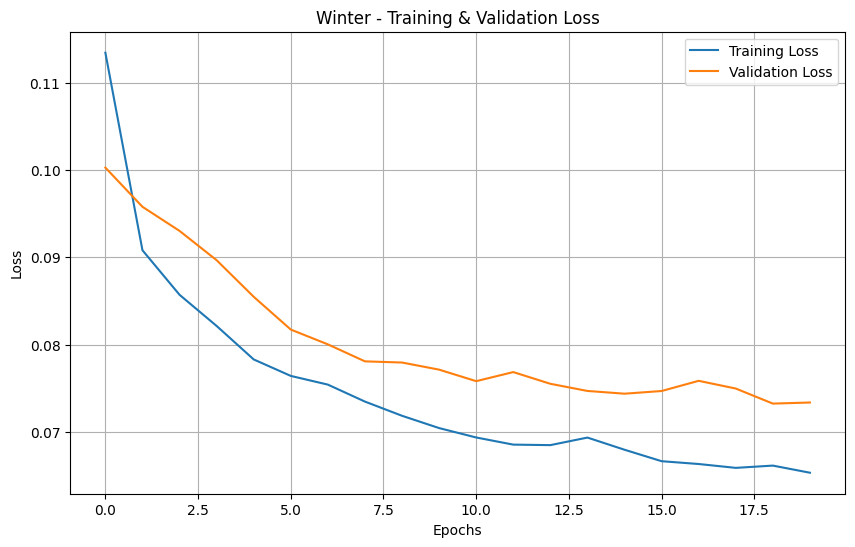

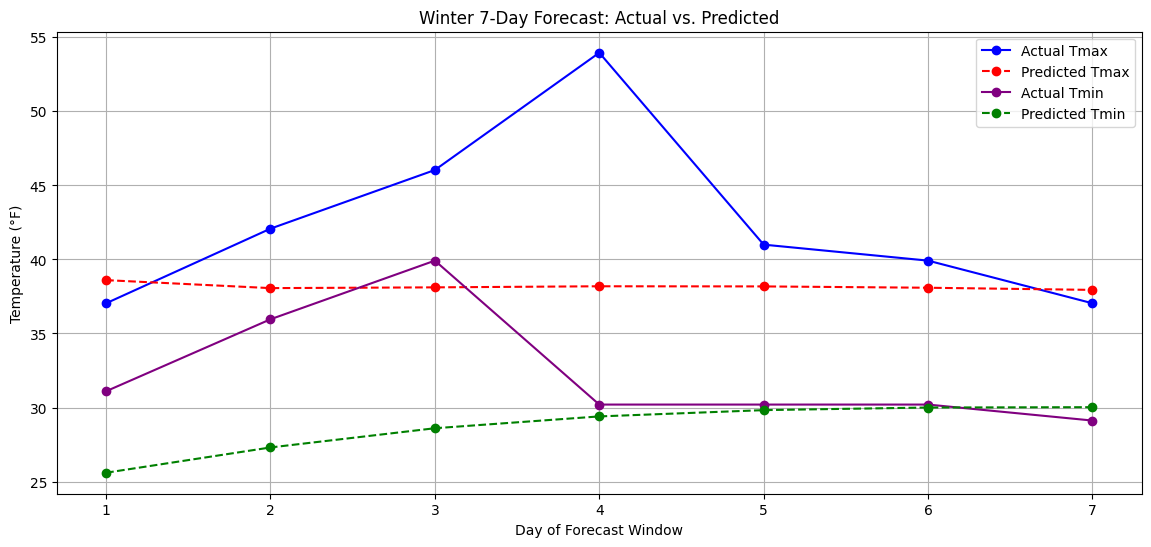

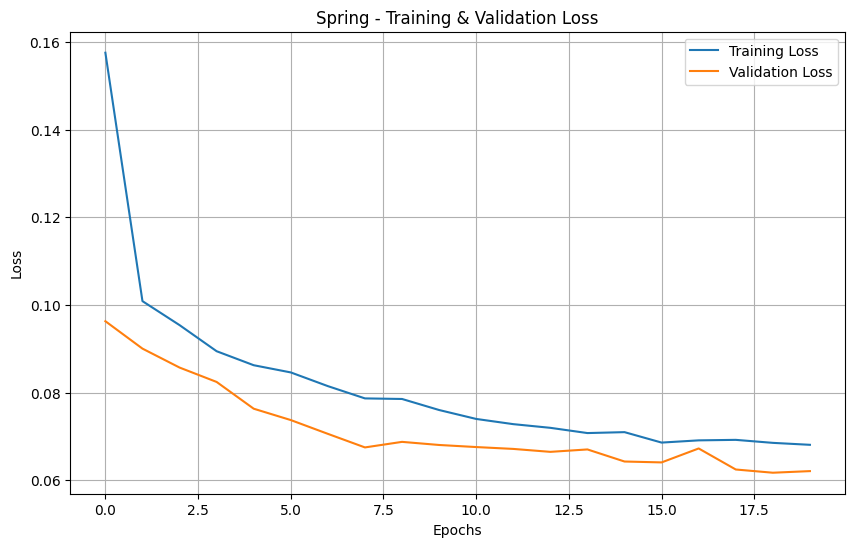

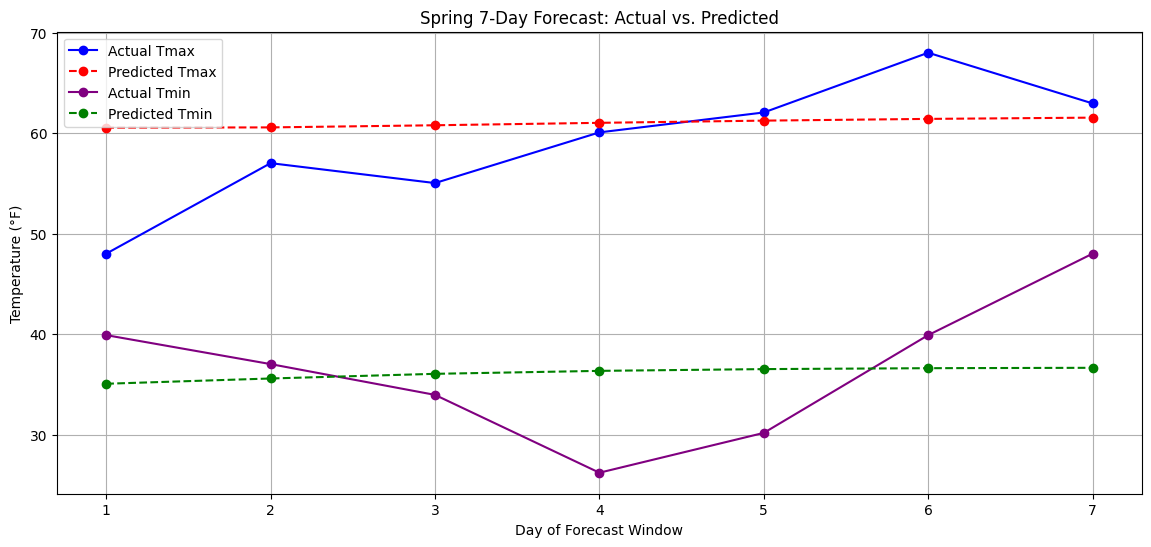

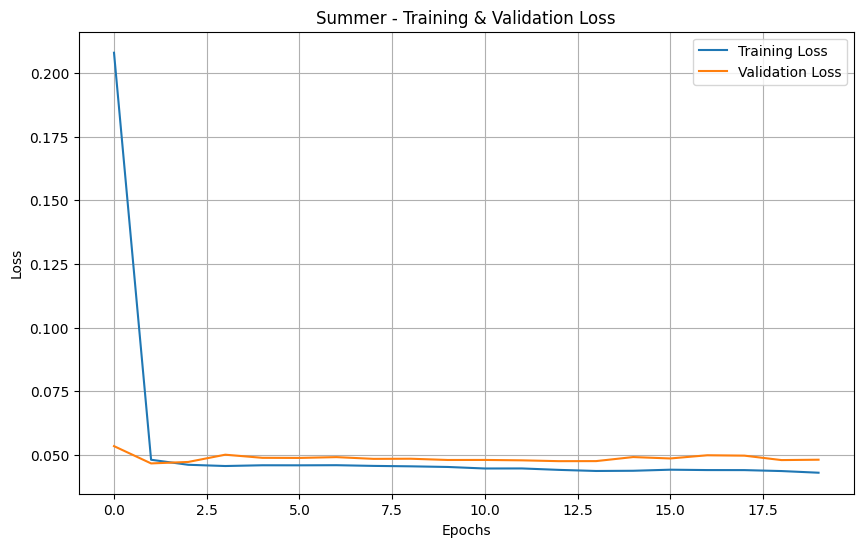

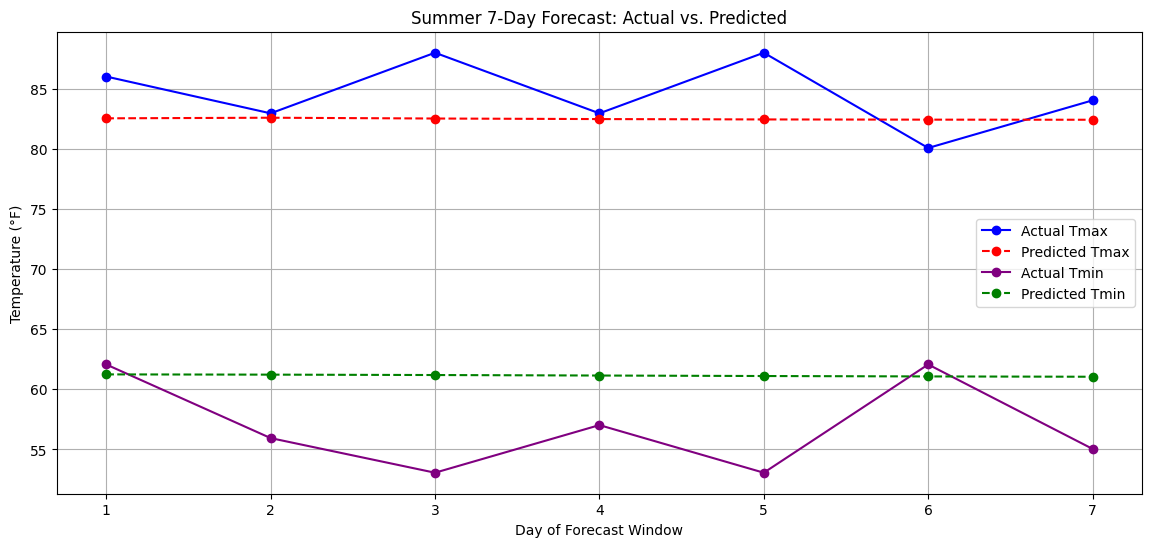

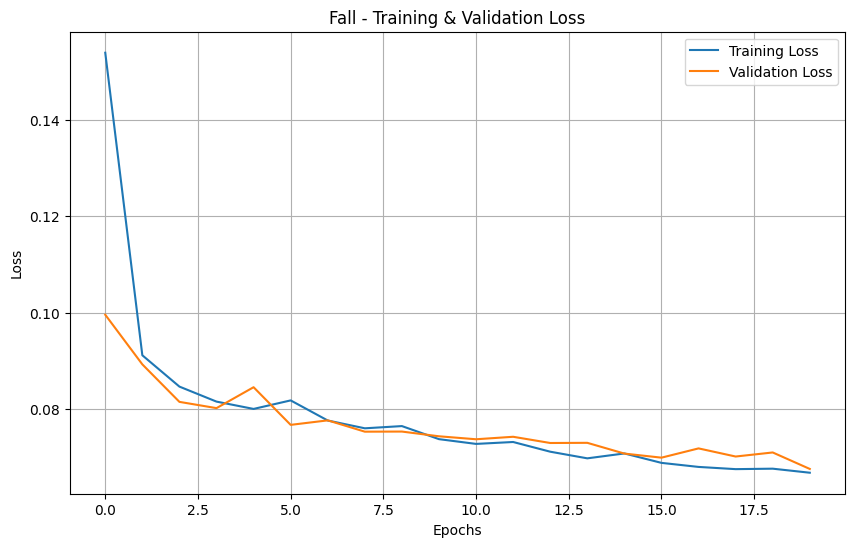

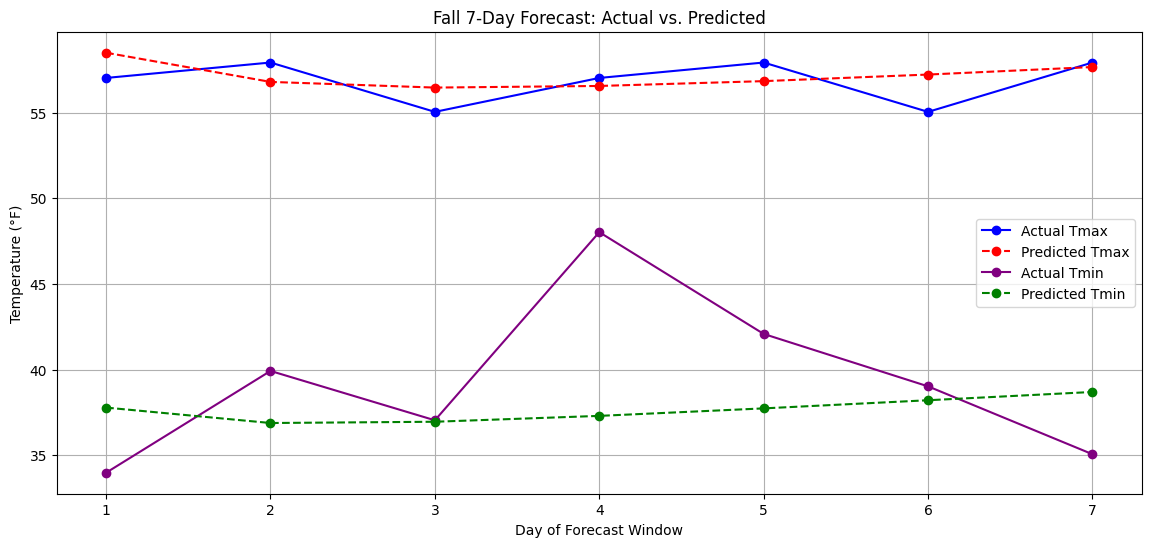

In [14]:
# Plot results for each seasonal forecasting period
plot_results(hist_winter, pred_real_winter, true_real_winter, "Winter")
plot_results(hist_spring, pred_real_spring, true_real_spring, "Spring")
plot_results(hist_summer, pred_real_summer, true_real_summer, "Summer")
plot_results(hist_fall, pred_real_fall, true_real_fall, "Fall")